# House Prices Prediction using Multiple Linear Regression

## 1. Importing libraries

In [203]:
import numpy as np
import pandas as pd

from matplotlib.pyplot import subplots
import statsmodels.api as sm

from statsmodels.stats.outliers_influence \
    import variance_inflation_factor as VIF

from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

from sklearn.metrics import mean_squared_error

## 2. Exploratory Data Analysis

In [33]:
training_data = pd.read_csv('data/train.csv', index_col = 'Id')
training_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


In [13]:
training_data.describe()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [14]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

My initial observations are that there are:
- 1460 observations.
- 37 numerical variables.
- 43 categorical variables.

In [34]:
missing = pd.DataFrame({
    'Missing' : training_data.isnull().sum(),
    'Percent' : 100 * training_data.isnull().mean()
})

missing = missing[missing['Missing'] > 0]
missing.sort_values('Percent', ascending = False)

,Missing,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


Here we explore how many entries are missing in each of the variables. We do not discard the missing entries immediately as some may still carry useful information. 
For example a missing entry in the PoolQC variable indicates no pool present at the house. 

### Summary of Preprocessing Decisions

| Variable(s) | Treatment | Justification |
|:------------|:---------|:--------------|
| PoolQC, MiscFeature, Alley, Fence | Remove | Too few observations to estimate their effects reliably. |
| MasVnrType, FireplaceQu, GarageType, GarageFinish, GarageQual, GarageCond, BsmtExposure, BsmtFinType1, BsmtFinType2, BsmtCond, BsmtQual | Replace with `"None"` | Missing values indicate that the feature is absent. |
| LotFrontage | Median imputation | Missing values likely represent unrecorded measurements. |
| GarageYrBlt | Replace with `0` | Missing values indicate the property has no garage. |
| MasVnrArea | Replace with `0` | Missing values correspond to `MasVnrType = "None"`. |
| Electrical | Remove observation | Only one observation is missing this value. |

In [35]:
drop_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
fill_none_cols = [
                  'MasVnrType', 'FireplaceQu', 'GarageType', 
                  'GarageFinish', 'GarageQual', 'GarageCond',
                  'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                  'BsmtCond', 'BsmtQual']

#Set the missing values in fill_none_cols columns list to None
for col in fill_none_cols:
    training_data[col] = training_data[col].fillna('None')

#Drop the columns in drop_cols list
training_data = training_data.drop(columns = drop_cols)
    
training_data['LotFrontage'] = (
    training_data['LotFrontage'].fillna(training_data['LotFrontage'].median()))

training_data['GarageYrBlt'] = training_data['GarageYrBlt'].fillna(0)

training_data['MasVnrArea'] = training_data['MasVnrArea'].fillna(0)

training_data = training_data.dropna(subset = ['Electrical'])

### Sale Price Distribution

<Axes: >

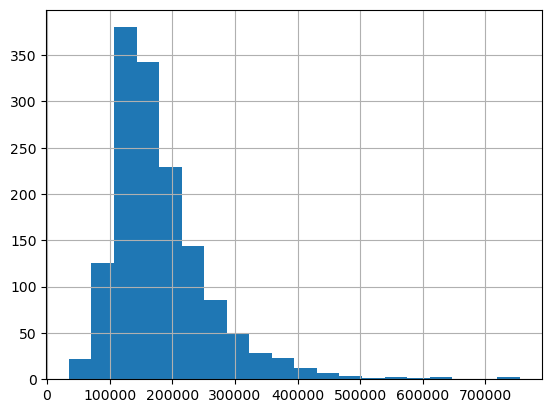

In [37]:
training_data['SalePrice'].hist(bins = 20)

In [38]:
training_data['SalePrice'].describe()

count      1459.000000
mean     180930.394791
std       79468.964025
min       34900.000000
25%      129950.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

The distribution of `SalePrice` is positively skewed, which may suggest that a logarithmic transformation may provide a more appropriate model for prediction. This will be investigated later using the regression diagnostics. There doesn't seem to any concerning outliers at first glance, but a proper check will be conducted.

In [41]:
corr = training_data.select_dtypes(include = 'number').corr()
saleprice_corr = (corr['SalePrice'].drop('SalePrice').sort_values(ascending = False))
saleprice_corr

OverallQual      0.791069
GrLivArea        0.708618
GarageCars       0.640473
GarageArea       0.623423
TotalBsmtSF      0.613905
1stFlrSF         0.605968
FullBath         0.560881
TotRmsAbvGrd     0.533779
YearBuilt        0.523273
YearRemodAdd     0.507430
MasVnrArea       0.472606
Fireplaces       0.466968
BsmtFinSF1       0.386436
LotFrontage      0.334793
WoodDeckSF       0.324422
2ndFlrSF         0.319464
OpenPorchSF      0.315831
HalfBath         0.284400
LotArea          0.263837
GarageYrBlt      0.261413
BsmtFullBath     0.227082
BsmtUnfSF        0.214446
BedroomAbvGr     0.168235
ScreenPorch      0.111419
PoolArea         0.092397
MoSold           0.046380
3SsnPorch        0.044571
BsmtFinSF2      -0.011412
BsmtHalfBath    -0.016873
MiscVal         -0.021200
LowQualFinSF    -0.025620
YrSold          -0.028907
OverallCond     -0.077924
MSSubClass      -0.084230
EnclosedPorch   -0.128627
KitchenAbvGr    -0.135935
Name: SalePrice, dtype: float64

For the purposes of this exploratory analaysis, our attention will be focused on the numerical predictors whose correlation to `SalePrice` exceeds `0.6`, as these exhibit the strongest linear relationships with the response variable.


These include
- OverallQual
- GrLivArea
- GarageCars
- GarageArea
- TotalBsmtSF
- 1stFlrSF

It is worth noticing that GarageCars and GarageArea are both predictors regarding the size of the garage, one in car capacity and the other in square feet respectively. Consequently, these predictors are expected to exhibit a strong correlation with one another, potentially introducing multicollinearity. This will be investiagted during the model fitting using the Variance Inflation Factor (VIF).

We will now examine scatter plots of these variables against `SalePrice` to assess whether the relationships appear approximately linear, and identify any potential outliers.

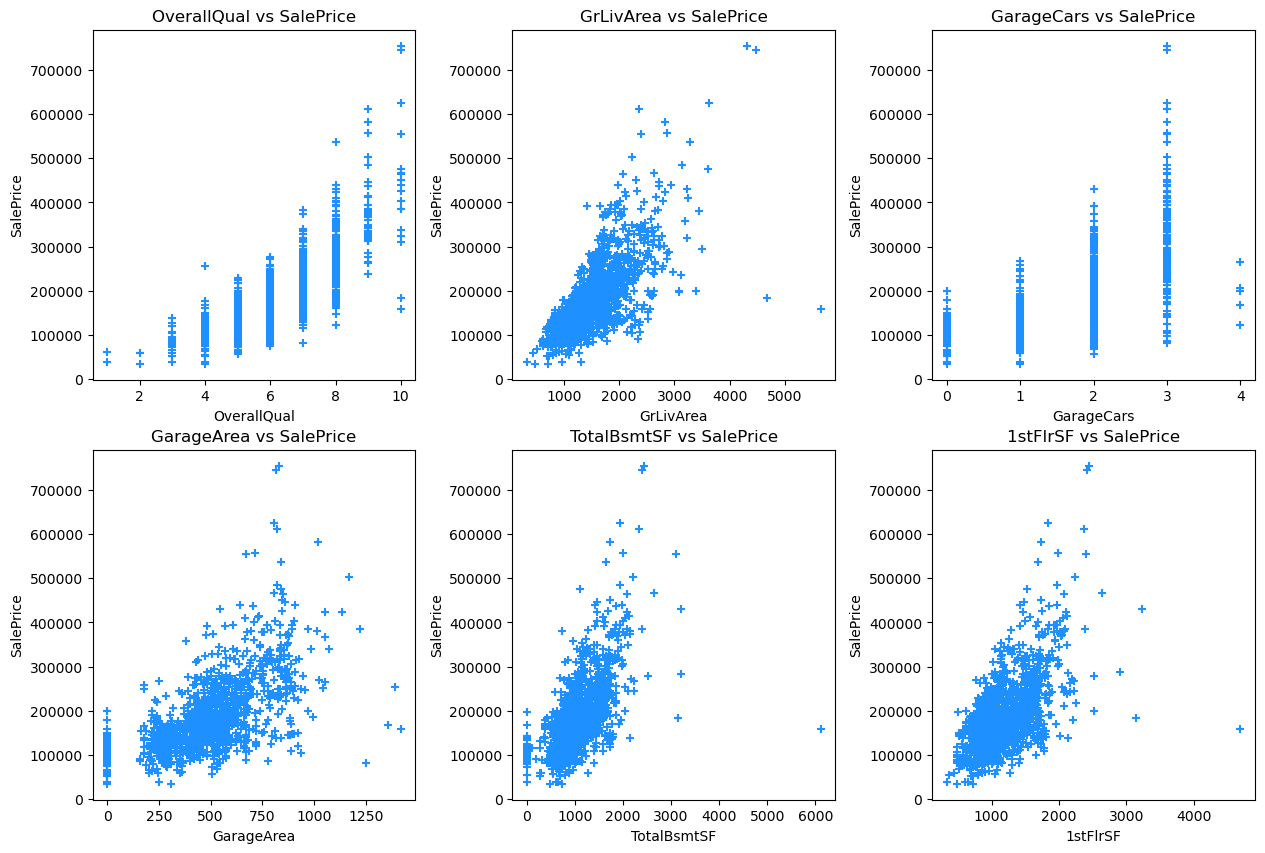

In [73]:
#Make a diagram with 2 rows and 3 columns of plots 
fig, ax = subplots(2, 3, figsize = (15, 10))

ax[0,0].scatter(training_data['OverallQual'], training_data['SalePrice'], marker = '+', color = 'dodgerblue')
ax[0,0].set_title('OverallQual vs SalePrice')
ax[0,0].set_xlabel('OverallQual')
ax[0,0].set_ylabel('SalePrice')

ax[0,1].scatter(training_data['GrLivArea'], training_data['SalePrice'], marker = '+', color = 'dodgerblue')
ax[0,1].set_title('GrLivArea vs SalePrice')
ax[0,1].set_xlabel('GrLivArea')
ax[0,1].set_ylabel('SalePrice')

ax[0,2].scatter(training_data['GarageCars'], training_data['SalePrice'], marker = '+', color = 'dodgerblue')
ax[0,2].set_title('GarageCars vs SalePrice')
ax[0,2].set_xlabel('GarageCars')
ax[0,2].set_ylabel('SalePrice')

ax[1,0].scatter(training_data['GarageArea'], training_data['SalePrice'], marker = '+', color = 'dodgerblue')
ax[1,0].set_title('GarageArea vs SalePrice')
ax[1,0].set_xlabel('GarageArea')
ax[1,0].set_ylabel('SalePrice')

ax[1,1].scatter(training_data['TotalBsmtSF'], training_data['SalePrice'], marker = '+', color = 'dodgerblue')
ax[1,1].set_title('TotalBsmtSF vs SalePrice')
ax[1,1].set_xlabel('TotalBsmtSF')
ax[1,1].set_ylabel('SalePrice')

ax[1,2].scatter(training_data['1stFlrSF'], training_data['SalePrice'], marker = '+', color = 'dodgerblue')
ax[1,2].set_title('1stFlrSF vs SalePrice')
ax[1,2].set_xlabel('1stFlrSF')
ax[1,2].set_ylabel('SalePrice')

fig.subplots_adjust(wspace = 0.3, hspace = 0.2)


These scatter plots provide supporting evidence that there are approximately linear relationships between these predictors and the response variable. This is perhaps seen most prominently in the `GrLivArea` vs `SalePrice` plot. 

Even though `GarageCars` is a discrete numerical predictor, it still has a strong positive association to `SalePrice` and will be worth keeping in the initial model to investigate it's effect.

Some potential outliers can be seen on the `TotalBsmtSF` and `1stFlrSf` plots, these will be assessed further using the regression diagnostics.

## 3. Model Fitting

We will first fit an initial model which includes the 6 predictors mentioned in EDA. A secondary model will later be fitted which will include all available predictors, including the categorical ones. The models will be compared using various methods such as adjusted $R^2$, residual standard error (RSE) and the ANOVA F-test.

In [86]:
y = training_data['SalePrice']
terms = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF']
X = MS(training_data[terms]).fit_transform(training_data)

initial_model = sm.OLS(y, X).fit()

categorical_cols = training_data.select_dtypes(include = 'object').columns
training_data[categorical_cols] = training_data[categorical_cols].astype('category')
secondary_terms = training_data.columns.drop('SalePrice')
L = MS(secondary_terms).fit_transform(training_data)

secondary_model = sm.OLS(y, L).fit()


In [94]:
print(f'Initial model R squared : {initial_model.rsquared:.4f}')
print(f'Initial model adjusted R squared : {initial_model.rsquared_adj:4f}')

print(f'Secondary model R squared : {secondary_model.rsquared:.4f}')
print(f'Secondary model adjusted R squared : {secondary_model.rsquared_adj:4f}')

Initial model R squared : 0.7621
Initial model adjusted R squared : 0.761079
Secondary model R squared : 0.9313
Secondary model adjusted R squared : 0.917939


In [95]:
anova_lm(initial_model, secondary_model)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1452.0,2.190867e+12,0.0,NaN,NaN,NaN
1,1220.0,6.322506e+11,232.0,1.558617e+12,12.963488,1.308108e-210


The usual $R^2$ value is the proportion of the variability in the response variable which is explained by the regression model.
It does not take into account the size of the model. Additional predictors can never decrease $R^2$, infact it can increase it just by pure coincidence rather than an genuine relationship with the response. 
Hence we consider the adjusted $R^2$ which penalises for inclusion of variables which don't improve the model.

The adjusted $R^2$ for the secondary model is `0.918`, which is much higher than the initial model's `0.761`, providing supporting evidence for the better suitability of the larger model. 

We've also conducted the ANOVA F-test which is appropriate in this situation as the larger model includes the smaller model within it.

The two models are:
$$
\begin{aligned}
M_1(initial):&\quad Y=\beta_0+\beta_1X_1+\cdots+\beta_6X_6+\varepsilon,\\[0.5em]
M_2(secondary):&\quad Y=\beta_0+\beta_1X_1+\cdots+\beta_pX_p+\varepsilon,
\end{aligned}
$$

The hypothese are 
$$
\begin{aligned}
H_0:&\quad \beta_7=\beta_8=\cdots=\beta_p=0,\\[0.5em]
H_1:&\quad \text{At least one of } \beta_7,\ldots,\beta_p \neq 0.
\end{aligned}
$$

The $p$ value obtained for this test is so small, that it is practically zero. Hence there is enough evidence to reject $H_0$ and support that the additional variables collectively provide an improvement to the model.

## 4. Regression Diagnostics

We will continue working with the secondary model and assess it's suitability using some diagnostic plots such as residuals against fitted values to assess whether the assumptions for a linear model hold. We will also look for outliers using studentized residuals and also analyse any high leverage data points. 

Firstly we will calculate the VIF for each variable and make decisions on whether they should be kept in the model.


In [99]:
vif = pd.DataFrame({
    'Variable' : L.columns,
    'VIF' : [VIF(L.values, i) for i in range(L.shape[1])]
})
vif.sort_values('VIF', ascending = False).head(20)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
159,BsmtUnfSF,inf
208,GarageFinish[None],inf
177,LowQualFinSF,inf
178,GrLivArea,inf
160,TotalBsmtSF,inf
158,BsmtFinSF2,inf
206,GarageType[None],inf
151,BsmtFinSF1,inf
148,BsmtFinType1[None],inf
175,1stFlrSF,inf


In [113]:
print((L['GarageType[None]'] == L['GarageFinish[None]']).all())
print((L['BsmtCond[None]'] == L['BsmtQual[None]']).all())
print((L['Exterior1st[CBlock]'] == L['Exterior2nd[CBlock]']).all())

True
True
True


We notice that some predictors have infinite VIF values. This is due to two types of dependencies which were identified.
Firstly we have the dependency involving the categorical variables which represent the abscence of house features.For example if a house has no Garage, i.e `GarageType = None`, then we immediately know the values of `GarageQual`, `GarageCond` and `GarageFinish` which would also return `None`.The basement `None` variables are also in a similar situation.

We also have another type of dependecy which is for engineered variables such as `GrLivArea` and `TotalBsmtSF` which are the sums of their component variables.

The modelling decisions made are:
- remove the components of the engineered variables and keep the engineered variables.
- keep a single representitive `None` indicator for each feature and remove the remaining redudant dummy variables.


In [151]:
remove_cols = ['1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
               'BsmtFinSF2', 'BsmtFinSF1', 'BsmtUnfSF',
               'GarageFinish[None]', 'GarageQual[None]',
               'GarageCond[None]', 'BsmtFinType1[None]', 'BsmtCond[None]', 
               'Exterior2nd[CBlock]']

L_reduced = L.drop(columns = remove_cols)

vif = pd.DataFrame({
    'Variable' : L_reduced.columns,
    'VIF' : [VIF(L_reduced.values, i) for i in range(L_reduced.shape[1])]
})
vif.sort_values('VIF', ascending = False).head(20).round(2)

,Variable,VIF
0,intercept,3118399.43
197,GarageType[None],2186.82
198,GarageYrBlt,2162.95
210,GarageCond[TA],272.32
206,GarageQual[TA],223.24
76,RoofStyle[Gable],161.62
78,RoofStyle[Hip],150.23
99,Exterior1st[VinylSd],112.49
113,Exterior2nd[VinylSd],104.49
134,BsmtQual[None],90.11


We have sucessfully removed all variables with infinite VIF. Now we will examine the variables with very high (greater than 10) VIF values, if there are any.

In [127]:
high_vif = vif[vif['VIF'] > 10]
high_vif.sort_values('VIF', ascending = False).round(2)

,Variable,VIF
0,intercept,3118399.43
197,GarageType[None],2186.82
198,GarageYrBlt,2162.95
210,GarageCond[TA],272.32
206,GarageQual[TA],223.24
...,...,...
28,Neighborhood[Edwards],11.50
115,Exterior2nd[Wd Shng],11.06
178,KitchenQual[TA],10.87
157,Heating[Grav],10.63


There are still variables with extremely high VIF values. The `GarageType[None]` is high correlated to the `GarageYrBlt` as if there is no garage then the year built it automatically set to `0`. We will now fit the model again and examine the $p$ values of the variables with very high VIF values.

In [141]:
secondary_model_update1 = sm.OLS(y, L_reduced).fit()
summary_update1 = summarize(secondary_model_update1)

summary_update1[summary_update1.index.str.contains('Garage')]

,coef,std err,t,P>|t|
GarageType[Attchd],22310.0000,11200.000,1.997,0.046
GarageType[Basment],21450.0000,12900.000,1.661,0.097
GarageType[BuiltIn],23430.0000,11600.000,2.018,0.044
GarageType[CarPort],27110.0000,14900.000,1.820,0.069
GarageType[Detchd],24770.0000,11200.000,2.213,0.027
GarageType[None],-39170.0000,124000.000,-0.316,0.752
GarageYrBlt,-30.1346,62.265,-0.484,0.628
GarageFinish[RFn],-3453.9234,1998.635,-1.728,0.084
GarageFinish[Unf],-586.5607,2458.618,-0.239,0.811
GarageCars,3465.8235,2320.578,1.494,0.136


We see that the variables `GarageType[None]` and `GarageYrBlt` have extremely high VIF and very high $p$ values aswell, `0.752` and `0.628` respectively. 
However due to the correlation mentioned between the two variables earlier I believe that after removing the `GarageYrBlt` variable we will significantly reduce the VIF for `GarageType[None]`. 

In [148]:
L_reduced_2 = L_reduced.drop(columns = 'GarageYrBlt')
secondary_model_update2 = sm.OLS(y, L_reduced_2).fit()
vif = pd.DataFrame({
    'Variable' : L_reduced_2.columns,
    'VIF' : [VIF(L_reduced_2.values, i) for i in range(L_reduced_2.shape[1])]
})
high_vif = vif[vif['VIF'] > 10]
high_vif.sort_values('VIF', ascending = False).round(2).head(20)

,Variable,VIF
0,intercept,3101738.73
209,GarageCond[TA],272.32
205,GarageQual[TA],222.94
76,RoofStyle[Gable],161.52
78,RoofStyle[Hip],150.13
99,Exterior1st[VinylSd],112.46
113,Exterior2nd[VinylSd],104.40
134,BsmtQual[None],90.09
126,ExterCond[TA],89.53
192,GarageType[Attchd],81.29


In [147]:
summary_update2 = summarize(secondary_model_update2)
summary_update2[summary_update2.index.str.contains('Garage')]

,coef,std err,t,P>|t|
GarageType[Attchd],22080.0000,11200.000,1.979,0.048
GarageType[Basment],21400.0000,12900.000,1.658,0.098
GarageType[BuiltIn],23170.0000,11600.000,1.997,0.046
GarageType[CarPort],26690.0000,14900.000,1.795,0.073
GarageType[Detchd],24490.0000,11200.000,2.192,0.029
GarageType[None],19980.0000,21100.000,0.946,0.344
GarageFinish[RFn],-3410.8959,1996.032,-1.709,0.088
GarageFinish[Unf],-526.8605,2454.754,-0.215,0.830
GarageCars,3431.1699,2318.748,1.480,0.139
GarageArea,19.4412,7.805,2.491,0.013


A lot of the garage variables have very low $p$ values, making them statistically significant in relation to the response variable. Hence we will keep them in the model even though they have high VIF values.
Next we turn our attention to other potential high VIF and high $p$ value variables by examining the 'Roof' variables.

In [149]:
summary_update2[summary_update2.index.str.contains('Roof')]

,coef,std err,t,P>|t|
RoofStyle[Gable],2415.9800,18700.0,0.129,0.897
RoofStyle[Gambrel],7728.8458,20400.0,0.379,0.705
RoofStyle[Hip],2884.1276,18700.0,0.154,0.878
RoofStyle[Mansard],16730.0000,21700.0,0.771,0.441
RoofStyle[Shed],98410.0000,35200.0,2.794,0.005
RoofMatl[CompShg],627400.0000,33200.0,18.898,0.000
RoofMatl[Membran],711700.0000,48000.0,14.837,0.000
RoofMatl[Metal],687800.0000,47100.0,14.611,0.000
RoofMatl[Roll],612000.0000,41800.0,14.651,0.000
RoofMatl[Tar&Grv],626100.0000,38000.0,16.463,0.000


From these tables it seems that the RoofStyle variables is worth investigating. 
We will not build a new model which doesn't include any of the RoofStyle variables and ask whether or not once we include all of them the model is improved. This will be done using an ANOVA-F test once again. 

In [150]:
L_no_roofstyle = L_reduced_2.drop(
    columns = L_reduced_2.filter(regex = r'^RoofStyle\[').columns
)
model_noroofstyle = sm.OLS(y, L_no_roofstyle).fit()
anova_lm(model_noroofstyle, secondary_model_update2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1230.0,6.646451e+11,0.0,NaN,NaN,NaN
1,1225.0,6.589732e+11,5.0,5.671925e+09,2.108768,0.061972


Throughout this project a significant level of $5%$ has been kept in mind. The $p$ value for this test exceeds that significance level, hence there is not enough evidence to support the claim that including RoofStyle significantly improves the model, hence it is removed.

In [155]:
vif = pd.DataFrame({
    'Variable' : L_no_roofstyle.columns,
    'VIF' : [VIF(L_no_roofstyle.values, i) for i in range(L_no_roofstyle.shape[1])]
})
high_vif = vif[vif['VIF'] > 10]
high_vif.sort_values('VIF', ascending = False).round(2).head(20)

,Variable,VIF
0,intercept,3096697.71
204,GarageCond[TA],271.89
200,GarageQual[TA],222.67
94,Exterior1st[VinylSd],112.21
108,Exterior2nd[VinylSd],104.12
129,BsmtQual[None],89.93
121,ExterCond[TA],84.82
187,GarageType[Attchd],81.08
197,GarageQual[Fa],78.75
201,GarageCond[Fa],77.84


The next focus is the `Exterior1st` and `Exterior2nd` variables. The same approach will be taken as with the `RoofStyle` variables.

In [157]:
summary_update3= summarize(model_noroofstyle)
summary_update3[summary_update3.index.str.contains('Exterior1st')]

,coef,std err,t,P>|t|
Exterior1st[AsphShn],-33520.0000,33100.0,-1.013,0.311
Exterior1st[BrkComm],-4476.1019,28200.0,-0.159,0.874
Exterior1st[BrkFace],7422.8833,13000.0,0.571,0.568
Exterior1st[CBlock],-15730.0000,27700.0,-0.567,0.571
Exterior1st[CemntBd],-5208.6294,19400.0,-0.269,0.788
Exterior1st[HdBoard],-14320.0000,13200.0,-1.088,0.277
Exterior1st[ImStucc],-35530.0000,28400.0,-1.252,0.211
Exterior1st[MetalSd],-5645.8445,14900.0,-0.379,0.705
Exterior1st[Plywood],-15160.0000,13000.0,-1.169,0.243
Exterior1st[Stone],-19380.0000,24200.0,-0.801,0.423


In [158]:
summary_update3[summary_update3.index.str.contains('Exterior2nd')]

,coef,std err,t,P>|t|
Exterior2nd[AsphShn],15680.0000,21500.0,0.727,0.467
Exterior2nd[Brk Cmn],1050.9084,20500.0,0.051,0.959
Exterior2nd[BrkFace],2797.9340,13500.0,0.208,0.835
Exterior2nd[CmentBd],5403.7955,19100.0,0.283,0.777
Exterior2nd[HdBoard],9490.4721,12700.0,0.749,0.454
Exterior2nd[ImStucc],28350.0000,14500.0,1.953,0.051
Exterior2nd[MetalSd],4186.9944,14500.0,0.288,0.773
Exterior2nd[Other],-9663.4123,27800.0,-0.348,0.728
Exterior2nd[Plywood],6318.1825,12300.0,0.514,0.608
Exterior2nd[Stone],-9623.9094,17500.0,-0.550,0.582


Almost all variables here are insignificant, hence we will fit a model without `Exterior2nd` and test using the ANOVA-F test once again.

In [159]:
L_no_exterior2nd = L_no_roofstyle.drop(
    columns = L_no_roofstyle.filter(regex = r'^Exterior2nd\[').columns
)

model_no_exterior2nd = sm.OLS(y, L_no_exterior2nd).fit()
anova_lm(model_no_exterior2nd, model_noroofstyle)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1244.0,6.709008e+11,0.0,NaN,NaN,NaN
1,1230.0,6.646451e+11,14.0,6.255655e+09,0.826913,0.640092


The test $p$ value is `0.64` which is way bigger than the $5\%$ significance level. There is not enough evidence to suggest that including `Exterior2nd` variables improves the model fit, hence we remove it.

In [160]:
vif = pd.DataFrame({
    'Variable' : L_no_exterior2nd.columns,
    'VIF' : [VIF(L_no_exterior2nd.values, i) for i in range(L_no_exterior2nd.shape[1])]
})
high_vif = vif[vif['VIF'] > 10]
high_vif.sort_values('VIF', ascending = False).round(2).head(20)

,Variable,VIF
0,intercept,3070111.18
190,GarageCond[TA],270.63
186,GarageQual[TA],221.74
115,BsmtQual[None],89.33
107,ExterCond[TA],84.72
183,GarageQual[Fa],78.38
173,GarageType[Attchd],78.19
187,GarageCond[Fa],77.46
105,ExterCond[Gd],71.57
177,GarageType[Detchd],63.12


In [161]:
summary_update4 = summarize(model_no_exterior2nd)
summary_update4[summary_update4.index.str.contains('Garage')]

,coef,std err,t,P>|t|
GarageType[Attchd],21160.0000,11000.000,1.931,0.054
GarageType[Basment],21260.0000,12600.000,1.682,0.093
GarageType[BuiltIn],22170.0000,11400.000,1.942,0.052
GarageType[CarPort],23580.0000,14500.000,1.630,0.103
GarageType[Detchd],23450.0000,10900.000,2.143,0.032
GarageType[None],18830.0000,21000.000,0.896,0.370
GarageFinish[RFn],-3602.4573,1981.314,-1.818,0.069
GarageFinish[Unf],-560.1883,2430.137,-0.231,0.818
GarageCars,3202.6358,2306.407,1.389,0.165
GarageArea,20.2687,7.719,2.626,0.009


We now investigate the `GarageType` variables as they remain the weakest within the Garage group. Procedure is the same as the last few variables, we fit models with and without and compare them.

In [163]:
L_no_garagetype = L_no_exterior2nd.drop(
    columns = L_no_exterior2nd.filter(regex = r'^GarageType\[').columns
)

model_no_garagetype = sm.OLS(y, L_no_garagetype).fit()
anova_lm(model_no_garagetype, model_no_exterior2nd)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1250.0,6.738230e+11,0.0,NaN,NaN,NaN
1,1244.0,6.709008e+11,6.0,2.922178e+09,0.903062,0.491754


The $p$ value for this test is `0.49`, which is once again way higher than the significance level. Hence there is not enough evidence to suggest that including the GarageType variables improves the model fit, so we remove them.

In [164]:
vif = pd.DataFrame({
    'Variable' : L_no_garagetype.columns,
    'VIF' : [VIF(L_no_garagetype.values, i) for i in range(L_no_garagetype.shape[1])]
})
high_vif = vif[vif['VIF'] > 10]
high_vif.sort_values('VIF', ascending = False).round(2).head(20)

,Variable,VIF
0,intercept,3037149.61
180,GarageQual[TA],221.21
184,GarageCond[TA],208.06
115,BsmtQual[None],88.97
107,ExterCond[TA],84.63
177,GarageQual[Fa],78.15
105,ExterCond[Gd],71.51
181,GarageCond[Fa],59.74
76,RoofMatl[CompShg],51.30
201,SaleType[New],51.01


In [165]:
summary_update5 = summarize(model_no_garagetype)
summary_update5[summary_update5.index.str.contains('Garage')]

,coef,std err,t,P>|t|
GarageFinish[RFn],-3738.3218,1963.632,-1.904,0.057
GarageFinish[Unf],90.2009,2347.238,0.038,0.969
GarageCars,3207.7569,2295.136,1.398,0.162
GarageArea,19.1428,7.510,2.549,0.011
GarageQual[Fa],-113400.0000,30100.000,-3.764,0.000
GarageQual[Gd],-103600.0000,30900.000,-3.349,0.001
GarageQual[Po],-125300.0000,38600.000,-3.244,0.001
GarageQual[TA],-107700.0000,29900.000,-3.606,0.000
GarageCond[Fa],101500.0000,30700.000,3.307,0.001
GarageCond[Gd],96970.0000,32000.000,3.033,0.002


We will perform the same type of test for GarageFinish and GarageCars.

In [166]:
L_no_garagefinish = L_no_garagetype.drop(
    columns = L_no_garagetype.filter(regex = r'GarageFinish\[').columns
)
model_no_garagefinish = sm.OLS(y, L_no_garagefinish).fit()
anova_lm(model_no_garagefinish, model_no_garagetype)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1252.0,6.767080e+11,0.0,NaN,NaN,NaN
1,1250.0,6.738230e+11,2.0,2.885004e+09,2.675967,0.069235


The $p$ value for this test is `0.069235` which is bigger than the significance level of `0.05` chosen throughout this project. Hence there is not enough evidence to suggest that keeping the `GarageFinish` variables improves the model fit siginficantly.

In [167]:
summary_update6 = summarize(model_no_garagefinish)
summary_update6[summary_update6.index.str.contains('Garage')]

,coef,std err,t,P>|t|
GarageCars,3581.114,2292.439,1.562,0.119
GarageArea,18.132,7.505,2.416,0.016
GarageQual[Fa],-112100.000,30100.000,-3.720,0.000
GarageQual[Gd],-102800.000,30900.000,-3.323,0.001
GarageQual[Po],-122900.000,38700.000,-3.179,0.002
GarageQual[TA],-106400.000,29900.000,-3.565,0.000
GarageCond[Fa],100100.000,30500.000,3.279,0.001
GarageCond[Gd],94200.000,31800.000,2.960,0.003
GarageCond[Po],103400.000,33300.000,3.108,0.002
GarageCond[TA],100000.000,30200.000,3.313,0.001


In [168]:
vif = pd.DataFrame({
    'Variable' : L_no_garagefinish.columns,
    'VIF' : [VIF(L_no_garagefinish.values, i) for i in range(L_no_garagefinish.shape[1])]
})
high_vif = vif[vif['VIF'] > 10]
high_vif.sort_values('VIF', ascending = False).round(2).head(20)

,Variable,VIF
0,intercept,3032020.43
178,GarageQual[TA],220.59
182,GarageCond[TA],205.20
115,BsmtQual[None],88.92
107,ExterCond[TA],84.59
175,GarageQual[Fa],77.98
105,ExterCond[Gd],71.48
179,GarageCond[Fa],58.95
76,RoofMatl[CompShg],51.19
199,SaleType[New],50.92


We remove the `GarageCars` variable as it is a numerical predictor with a $p$ value bigger than `0.05`. There is no need for an ANOVA-F test here as it will produce the same conclusion as the t-statistic test.

In [169]:
L_no_garagecars = L_no_garagefinish.drop(columns = 'GarageCars')
model_no_garagecars = sm.OLS(y, L_no_garagecars).fit()
vif = pd.DataFrame({
    'Variable' : L_no_garagecars.columns,
    'VIF' : [VIF(L_no_garagecars.values, i) for i in range(L_no_garagecars.shape[1])]
})
high_vif = vif[vif['VIF'] > 10]
high_vif.sort_values('VIF', ascending = False).round(2).head(20)

,Variable,VIF
0,intercept,3031840.70
177,GarageQual[TA],220.38
181,GarageCond[TA],204.12
115,BsmtQual[None],88.90
107,ExterCond[TA],84.39
174,GarageQual[Fa],77.89
105,ExterCond[Gd],71.25
178,GarageCond[Fa],58.54
198,SaleType[New],50.89
76,RoofMatl[CompShg],49.28


Next variables of interest are the group `SaleCondition`

In [170]:
L_no_salecondition = L_no_garagecars.drop(
    columns = L_no_garagecars.filter(regex = r'SaleCondition\[').columns
)
model_no_salecondition = sm.OLS(y, L_no_salecondition).fit()
anova_lm(model_no_salecondition, model_no_garagecars)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1258.0,6.805805e+11,0.0,NaN,NaN,NaN
1,1253.0,6.780269e+11,5.0,2.553569e+09,0.943804,0.45154


The $p$ value for this test is `0.45` which is higher than the significance level, hence there is not enough evidence to support the claim that including `SaleCondition` will improve the model fit, so we remove it.

In [171]:
vif = pd.DataFrame({
    'Variable' : L_no_salecondition.columns,
    'VIF' : [VIF(L_no_salecondition.values, i) for i in range(L_no_salecondition.shape[1])]
})
high_vif = vif[vif['VIF'] > 10]
high_vif.sort_values('VIF', ascending = False).round(2).head(20)

,Variable,VIF
0,intercept,3006724.79
177,GarageQual[TA],220.02
181,GarageCond[TA],203.65
115,BsmtQual[None],88.82
107,ExterCond[TA],84.32
174,GarageQual[Fa],77.75
105,ExterCond[Gd],71.20
178,GarageCond[Fa],58.35
76,RoofMatl[CompShg],49.11
4,MSZoning[RL],46.62


In [172]:
summary_update7 = summarize(model_no_salecondition)
summary_update7[summary_update7.index.str.contains('RoofMatl')]

,coef,std err,t,P>|t|
RoofMatl[CompShg],638600.0,32300.0,19.798,0.0
RoofMatl[Membran],705800.0,43200.0,16.339,0.0
RoofMatl[Metal],687100.0,42300.0,16.261,0.0
RoofMatl[Roll],626000.0,41000.0,15.276,0.0
RoofMatl[Tar&Grv],629700.0,33300.0,18.910,0.0
RoofMatl[WdShake],654600.0,34800.0,18.800,0.0
RoofMatl[WdShngl],689000.0,33600.0,20.492,0.0


Even though the `RoofMatl[CompShg]` variable had a very high VIF of about `49`, all of the related variables have $p$ values of `0`, hence we do not remove them from the mode as they are all statistically significant.

For similar reasoning we also leave `GarageQual` and `GarageCond` in the model as their $p$ values are also very low, and hence their bring valuable information to the model.

We will now report the latest model summar, and continue removing insiginificant variables in a similar fashion.

In [175]:
summary_update7.sort_values('P>|t|', ascending = False).head(20).round(4)

,coef,std err,t,P>|t|
EnclosedPorch,0.0645,12.506,0.005,0.996
BsmtFinType2[GLQ],-197.6958,9370.810,-0.021,0.983
HouseStyle[SLvl],-112.2123,5250.779,-0.021,0.983
BsmtQual[None],-1235.6620,36500.000,-0.034,0.973
HeatingQC[Po],1341.9742,27100.000,0.050,0.961
Condition2[Norm],1050.9516,19800.000,0.053,0.958
Neighborhood[Veenker],617.7871,10500.000,0.059,0.953
Neighborhood[BrDale],-773.0826,10900.000,-0.071,0.944
HouseStyle[2.5Unf],680.7907,9099.142,0.075,0.940
MiscVal,-0.1116,1.432,-0.078,0.938


In [176]:
L_no_heating = L_no_salecondition.drop(
    columns = L_no_salecondition.filter(regex = r'Heating\[').columns
)
model_no_heating = sm.OLS(y, L_no_heating).fit()
anova_lm(model_no_heating, model_no_salecondition)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1263.0,6.825103e+11,0.0,NaN,NaN,NaN
1,1258.0,6.805805e+11,5.0,1.929768e+09,0.713405,0.613392


Decision is to remove the `Heating` variable.

In [177]:
summary_update8 = summarize(model_no_heating)
summary_update8.sort_values('P>|t|', ascending = False).head(20).round(4)

,coef,std err,t,P>|t|
EnclosedPorch,0.2675,12.482,0.021,0.983
BsmtFinType2[GLQ],256.8213,9359.693,0.027,0.978
HeatingQC[Fa],-133.7707,4373.742,-0.031,0.976
BsmtQual[None],-1304.5892,36400.000,-0.036,0.971
HeatingQC[Po],1089.3079,27100.000,0.040,0.968
Neighborhood[Veenker],540.1119,10500.000,0.051,0.959
Exterior1st[MetalSd],386.9171,6512.086,0.059,0.953
Neighborhood[Blueste],-1269.3725,19300.000,-0.066,0.948
Condition2[Norm],1347.1653,19700.000,0.068,0.946
MiscVal,-0.1326,1.430,-0.093,0.926


In [184]:
L_no_enclosedporch = L_no_heating.drop(columns = 'EnclosedPorch')
model_no_enclosedporch = sm.OLS(y, L_no_enclosedporch).fit()
summary_update9 = summarize(model_no_enclosedporch)
summary_update9.sort_values('P>|t|', ascending = False).head(20).round(4)

,coef,std err,t,P>|t|
BsmtFinType2[GLQ],262.8092,9351.823,0.028,0.978
HeatingQC[Fa],-139.7317,4363.164,-0.032,0.974
BsmtQual[None],-1288.8111,36300.000,-0.035,0.972
HeatingQC[Po],1140.4951,26900.000,0.042,0.966
Neighborhood[Veenker],537.2731,10500.000,0.051,0.959
Exterior1st[MetalSd],382.1681,6505.742,0.059,0.953
Neighborhood[Blueste],-1281.9340,19300.000,-0.067,0.947
Condition2[Norm],1374.6479,19700.000,0.070,0.944
MiscVal,-0.1326,1.430,-0.093,0.926
Neighborhood[BrDale],-1079.0004,10900.000,-0.099,0.921


In [183]:
L_no_miscval = L_no_enclosedporch.drop(columns = 'MiscVal')
model_no_miscval = sm.OLS(y, L_no_miscval).fit()
summary_update10 = summarize(model_no_miscval)
summary_update10.sort_values('P>|t|', ascending = False).head(20).round(4)

,coef,std err,t,P>|t|
BsmtFinType2[GLQ],263.9436,9348.150,0.028,0.977
HeatingQC[Fa],-154.8267,4358.419,-0.036,0.972
BsmtQual[None],-1315.9233,36300.000,-0.036,0.971
HeatingQC[Po],1159.8978,26900.000,0.043,0.966
Neighborhood[Veenker],549.1573,10500.000,0.052,0.958
Exterior1st[MetalSd],366.7714,6501.075,0.056,0.955
Neighborhood[Blueste],-1262.1175,19300.000,-0.066,0.948
Condition2[Norm],1352.9006,19700.000,0.069,0.945
Neighborhood[BrDale],-1075.5987,10900.000,-0.099,0.921
Electrical[FuseP],-1750.6146,17300.000,-0.101,0.919


In [186]:
L_no_openporchsf = L_no_miscval.drop(columns = 'OpenPorchSF')
model_no_openporchsf = sm.OLS(y, L_no_openporchsf).fit()
summary_update11 = summarize(model_no_openporchsf)
summary_update11.sort_values('P>|t|', ascending = False).head(20).round(4)

,coef,std err,t,P>|t|
BsmtFinType2[GLQ],230.6418,9340.211,0.025,0.980
HeatingQC[Fa],-170.6171,4354.648,-0.039,0.969
BsmtQual[None],-1467.3223,36300.000,-0.040,0.968
HeatingQC[Po],1217.3700,26900.000,0.045,0.964
Neighborhood[Veenker],489.2159,10500.000,0.047,0.963
Exterior1st[MetalSd],327.0210,6489.734,0.050,0.960
Neighborhood[Blueste],-1289.2606,19300.000,-0.067,0.947
Condition2[Norm],1403.2706,19600.000,0.071,0.943
Electrical[FuseP],-1755.8009,17300.000,-0.101,0.919
Neighborhood[BrDale],-1165.2801,10900.000,-0.107,0.915


In [187]:
L_no_condition2 = L_no_openporchsf.drop(
    columns = L_no_openporchsf.filter(regex = r'Condition2\[').columns
)
model_no_condition2 = sm.OLS(y, L_no_condition2).fit()
anova_lm(model_no_condition2, model_no_openporchsf)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1273.0,7.577701e+11,0.0,NaN,NaN,NaN
1,1266.0,6.825226e+11,7.0,7.524749e+10,19.939333,1.744920e-25


Suprisingly, this is the first ANOVA-F test in which we actually reject the null hypothesis since we started simplifying the model. The $p$ value here is extremely small, hence there is evidence supporting the claim that including the `Condition2` varibales actually improves the model fit.

In [188]:
L_no_electrical = L_no_openporchsf.drop(
    columns = L_no_openporchsf.filter(regex = r'Electrical\[').columns
)
model_no_electrical = sm.OLS(y, L_no_electrical).fit()
anova_lm(model_no_electrical, model_no_openporchsf)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1270.0,6.829279e+11,0.0,NaN,NaN,NaN
1,1266.0,6.825226e+11,4.0,4.052381e+08,0.187917,0.94476


On this test however there is not enough evidence to support the claim that including the `Electrical` variables in the model improves it significantly, hence we remove them.

In [189]:
L_no_housestyle = L_no_electrical.drop(
    columns = L_no_electrical.filter(regex = r'HouseStyle\[').columns
)
model_no_housestyle = sm.OLS(y, L_no_housestyle).fit()
anova_lm(model_no_housestyle, model_no_electrical)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1277.0,6.899791e+11,0.0,NaN,NaN,NaN
1,1270.0,6.829279e+11,7.0,7.051212e+09,1.873245,0.070394


Once again, not enough evidence to support the claim that including the `HouseStyle` variables improve the model, hence we remove them.

In [190]:
L_no_heatingqc = L_no_housestyle.drop(
    columns = L_no_housestyle.filter(regex = r'HeatingQC\[').columns
)
model_no_heatingqc = sm.OLS(y, L_no_heatingqc).fit()
anova_lm(model_no_heatingqc, model_no_housestyle)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1281.0,6.914626e+11,0.0,NaN,NaN,NaN
1,1277.0,6.899791e+11,4.0,1.483505e+09,0.686411,0.601391


Once again, not enough evidence to support the claim that including the `HeatingQC` variables improve the model, hence we remove them.

In [192]:
L_no_exterior1st = L_no_heatingqc.drop(
    columns = L_no_heatingqc.filter(regex = r'Exterior1st\[').columns
)
model_no_exterior1st = sm.OLS(y, L_no_exterior1st).fit()
anova_lm(model_no_exterior1st, model_no_heatingqc)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1295.0,7.087618e+11,0.0,NaN,NaN,NaN
1,1281.0,6.914626e+11,14.0,1.729927e+10,2.289181,0.004274


There is enough evidence at the $5\%$ significance level to reject the null hypothesis in this ANOVA-F test. Hence there is evidence to support the claim that keeping the `Exterior1st` variables improves the model fit significantly.

In [193]:
summary_update12 = summarize(model_no_heatingqc)
summary_update12.sort_values('P>|t|', ascending = False).head(20).round(4)

,coef,std err,t,P>|t|
Neighborhood[Veenker],-585.3639,10500.000,-0.056,0.955
BsmtCond[Gd],-359.4734,5258.485,-0.068,0.946
BsmtQual[None],2633.5108,36000.000,0.073,0.942
BsmtFinType2[GLQ],807.7282,9277.338,0.087,0.931
Exterior1st[MetalSd],946.0750,6198.692,0.153,0.879
Exterior1st[Wd Sdng],-998.5439,6131.201,-0.163,0.871
ExterCond[Po],-5255.2038,31100.000,-0.169,0.866
Condition2[Norm],-3249.9774,19200.000,-0.169,0.866
Neighborhood[Blueste],-3506.3571,19200.000,-0.183,0.855
Exterior1st[VinylSd],-1140.8174,6185.731,-0.184,0.854


In [195]:
L_no_heatingqc.shape

(1459, 178)

In [196]:
L_no_condition1 = L_no_heatingqc.drop(
    columns = L_no_heatingqc.filter(regex = r'Condition1\[').columns
)
model_no_condition1 = sm.OLS(y, L_no_condition1).fit()
anova_lm(model_no_condition1, model_no_heatingqc)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1289.0,7.096691e+11,0.0,NaN,NaN,NaN
1,1281.0,6.914626e+11,8.0,1.820648e+10,4.216154,0.000053


We keep `Condition1`.

In [197]:
L_no_bsmtcond = L_no_heatingqc.drop(
    columns = L_no_heatingqc.filter(regex = r'BsmtCond\[').columns
)
model_no_bsmtcond = sm.OLS(y, L_no_bsmtcond).fit()
anova_lm(model_no_bsmtcond, model_no_heatingqc)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1284.0,6.945443e+11,0.0,NaN,NaN,NaN
1,1281.0,6.914626e+11,3.0,3.081708e+09,1.903052,0.127226


There is not enough evidence at the $5\%$ significance level to keep the `BsmtCond` variables in the model.

In [198]:
L_no_bsmtqual = L_no_bsmtcond.drop(
    columns = L_no_bsmtcond.filter(regex = r'BsmtQual\[').columns
)
model_no_bsmtqual = sm.OLS(y, L_no_bsmtqual).fit()
anova_lm(model_no_bsmtqual, model_no_bsmtcond)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1288.0,7.208542e+11,0.0,NaN,NaN,NaN
1,1284.0,6.945443e+11,4.0,2.630988e+10,12.159732,1.050218e-09


We keep `BsmtQual`.

After a large variable selection process, we decide to stop here. We have adressed the biggest issues which were present at first, which included infinite VIF values, obvious multicollinearities and insignificant continuous numerical predictor variables. We used the VIF tables along with the $p$ value tables to make a decision on whether a variable should potentially be removed, and additionally we used the ANOVA-F test to decide whether a categorical variable significantly improved the model fit. We will now report the adjusted $R^2$ value for the final model, aswell as the training MSE. 

In [214]:
model_final = model_no_bsmtcond
L_final = L_no_bsmtcond
